### Librerias

In [52]:
# Cargar de archivos de datos y librerías necesarias
import sys
sys.path.append("..")
from src.utils.constants import AGLOMERADOS_NOMBRES
from src.utils.constants import INDIVIDUOS_PROCESSED_DIR, HOGARES_PROCESSED_DIR

# Librerías para el análisis de datos
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
import pandas as pd
import streamlit as st

In [53]:
# Cargar datos procesados (asegúrate de tener bien la ruta)
df_individuos =pd.read_csv(INDIVIDUOS_PROCESSED_DIR, sep=";", encoding="utf-8",low_memory=False)

###  Creo mis dataset filtrado 

In [54]:
#Filtro mis columnas de interés
columnas_emp = ['AGLOMERADO', 'ANO4', 'TRIMESTRE', 'NIVEL_ED_str', 'CONDICION_LABORAL', 'PONDERA','PP04A']
df_empleo = df_individuos[columnas_emp].copy()


In [55]:
# Armo mis variables para filtrar el dateset
anio_trim = df_empleo.groupby('ANO4')['TRIMESTRE'].unique().apply(list).to_dict()
anio_trim

{2021: [2], 2022: [3], 2023: [1, 3]}

### 1.5.1 Para las personas desocupadas, informar la cantidad de ellas según sus estudios alcanzados. Se debe informar para un año y trimestre elegido por el usuario.

In [56]:
st.title("Análisis de Desocupados por Nivel Educativo")

# Configuro el selector de año y trimestre
anio = st.selectbox("Seleccioná un año",anio_trim.keys())
trimestre = st.selectbox("Seleccioná un año", anio_trim[anio])

# Filtro por año, trimestre y condición laboral

df_filtrado= df_empleo[(df_empleo['ANO4'] == anio) & (df_empleo['TRIMESTRE'] == trimestre) & (df_empleo['CONDICION_LABORAL'] == 'Desocupado')]

# Agrupar por nivel educativo
df_educacion_desocupado = df_filtrado.groupby('NIVEL_ED_str')['PONDERA'].sum().sort_values(ascending=False)
df_educacion_desocupado

2025-05-31 04:01:05.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.316 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.317 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.318 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.319 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.320 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.322 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.323 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

NIVEL_ED_str
Superior o universitario    447249
Secundario completo         391379
Secundario incompleto       290178
Primario completo           106527
Primario incompleto          32507
Sin Información               4662
Name: PONDERA, dtype: int64

#### Armo gráfico

Gráfico de barras


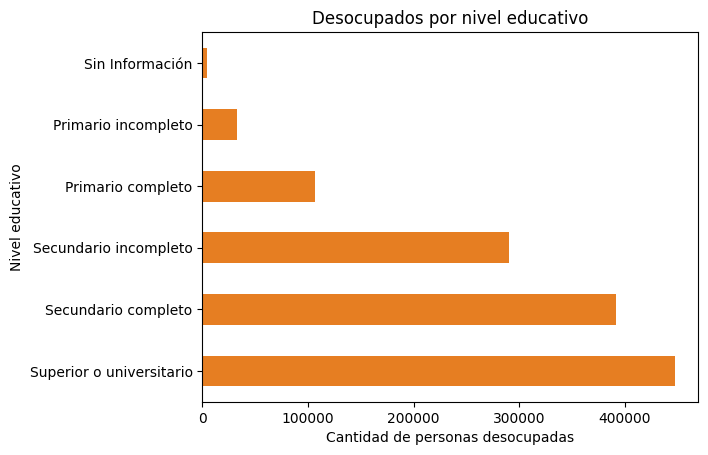

In [57]:

# Subtítulo (opcional en Jupyter, si querés podés imprimirlo)
print("Gráfico de barras")

# Crear la figura y el eje
fig, ax = plt.subplots()

# Dibujar el gráfico de barras horizontal
df_educacion_desocupado.plot(kind='barh', ax=ax, color="#E67E22")

# Etiquetas
ax.set_xlabel("Cantidad de personas desocupadas")
ax.set_ylabel("Nivel educativo")
ax.set_title("Desocupados por nivel educativo")

# Mostrar el gráfico
plt.show()

In [58]:
# Streamlit para mostrar el gráfico
st.subheader("Tabla de cantidad de desocupados por nivel educativo")
st.dataframe(df_educacion_desocupado.rename("Cantidad de Personas").to_frame())

2025-05-31 04:01:05.912 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:05.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

### 1.5.2 Informar la evolución del desempleo(tasa de desempleo) a lo largo del tiempo. Se debe poder filtrar por aglomerado y en caso de no elegir ninguno se debe calcular para todo el país. La tasa de desempleo es el cociente de personas desocupadas y la suma de personas desocupadas más ocupadas multiplicado por 100.

FUNCIONES BACK

In [59]:
#Funciones
def mapear_nombres_aglomerados(df) :
    print(df[['AGLOMERADO']].head())
    print(type(AGLOMERADOS_NOMBRES))
    print(type(df['AGLOMERADO']))
    df['AGLOMERADO_NOMBRE'] = df['AGLOMERADO'].map(AGLOMERADOS_NOMBRES)
    print(type(AGLOMERADOS_NOMBRES))

    return df

def calcular_tasa_emp_desemp(df, condicion='Desocupado', agrupacion=['ANO4', 'TRIMESTRE']):
    """
    Calcula la tasa de empleo o desempleo por las columnas que se pasen en 'agrupacion'.

    Parámetros:
    - df: DataFrame con las columnas 'CONDICION_LABORAL', 'PONDERA' y las que se agrupen
    - condicion: 'Desocupado' o 'Ocupado'
    - agrupacion: lista de columnas para agrupar dinámicamente (ej. ['ANO4', 'TRIMESTRE'], o ['REGION'])

    Devuelve:
    - DataFrame con la tasa calculada por grupo
    """
    nombre_tasa = "Desempleo" if condicion == 'Desocupado' else "Empleo"

    # Asegurarse de que agrupacion es lista (por si pasan string)
    if isinstance(agrupacion, str):
        agrupacion = [agrupacion]

    # Agrupar dinámicamente
    grupo = df.groupby(agrupacion)

    # Calcular la suma de ponderados por grupo para cada condición
    df_tasa = grupo.apply(lambda g: pd.Series({
        'Desocupado': g[g['CONDICION_LABORAL'] == 'Desocupado']['PONDERA'].sum(),
        'Ocupado': g[g['CONDICION_LABORAL'].str.contains('Ocupado', na=False)]['PONDERA'].sum()
    })).reset_index()

    # Calcular total
    total = df_tasa['Desocupado'] + df_tasa['Ocupado']

    # Calcular tasa
    df_tasa[f'Tasa de {nombre_tasa}'] = round((df_tasa[condicion] / total) * 100, 2)

    return df_tasa.sort_values(by=agrupacion)

def listar(df, columna):
    """Devuelve una lista de valores únicos de una columna del DataFrame."""
    return df[columna].unique().tolist()

def agregar_columna_fecha(df):
    """
    Agrega una columna 'Fecha' combinando ANO4 y TRIMESTRE para graficar series temporales.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'ANO4' y 'TRIMESTRE'.

    Returns:
        pd.DataFrame: DataFrame con la columna 'Fecha' como datetime.
    """
    df = df.copy()
    df['Fecha'] = df['ANO4'].astype(str) + '-T' + df['TRIMESTRE'].astype(str)
    return df

def graficar_tasa(df, columna_tasa, titulo):
    """
    Grafica la evolución temporal de una tasa usando Plotly.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'Fecha' y una tasa.
        columna_tasa (str): Nombre de la columna que contiene la tasa a graficar.
        titulo (str): Título del gráfico.
    """
    fig = px.line(df, x='Fecha', y=columna_tasa, title=titulo)
    fig.show()
    st.plotly_chart(fig)


PARTE EN STREAMLIT

In [60]:
# Título
st.title("Evolución de la tasa de desempleo")

#Listar Aglomerados
df_empleo=mapear_nombres_aglomerados(df_empleo)


aglomerados = listar(df_empleo, 'AGLOMERADO_NOMBRE')

# Mostrar el multiselect con los nombres de los aglomerados
seleccionados = st.multiselect("Seleccioná uno o más aglomerados (opcional)",options=aglomerados,default=aglomerados)

# Filtrar los datos solo con condiciones laborales válidas
df_filtrados = df_empleo[df_empleo['AGLOMERADO_NOMBRE'].isin(seleccionados)]   

# Filtrar las condiciones laborales válidas
condicion_valida =['Ocupado autónomo', 'Ocupado dependiente', 'Desocupado']
df_filtrado = df_filtrados[df_filtrados['CONDICION_LABORAL'].isin(condicion_valida)]

# Calcular suma de ponderaciones por grupo
df_tasa_desempleo = calcular_tasa_emp_desemp(df_filtrado, condicion='Desocupado')
df_tasa_desempleo

2025-05-31 04:01:06.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.023 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.070 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


   AGLOMERADO
0          91
1          91
2          91
3          91
4          91
<class 'dict'>
<class 'pandas.core.series.Series'>
<class 'dict'>


C:\Users\PC\AppData\Local\Temp\ipykernel_19440\3166244684.py:33: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,ANO4,TRIMESTRE,Desocupado,Ocupado,Tasa de Desempleo
0,2021,2,1272502,11981480,9.60
1,2022,3,988980,12922101,7.11
2,2023,1,973787,13191361,6.87
3,2023,3,813661,13396202,5.73


### 1.5.3
Informar la evolución del empleo (tasa de empleo) a lo largo del tiempo. Se debe poder
filtrar por aglomerado y en caso de no elegir ninguno se debe calcular para todo el país.
La tasa de empleo es el cociente entre personas ocupadas y la suma de personas
desocupadas más ocupadas multiplicado por 100.

PARTE EN STREAMLIT

In [61]:
# Título
st.title("Evolución de la tasa de empleo")

# Mostrar el multiselect con los nombres de los aglomerados
seleccionados = st.multiselect("Seleccioná uno o más aglomerados (opcional)",options=aglomerados,default=aglomerados)

# Filtrar los datos solo con condiciones laborales válidas
df_filtrados = df_empleo[df_empleo['AGLOMERADO_NOMBRE'].isin(seleccionados)]   

# Filtrar las condiciones laborales válidas
condicion_valida =['Ocupado autónomo', 'Ocupado dependiente', 'Desocupado']
df_filtrado = df_filtrados[df_filtrados['CONDICION_LABORAL'].isin(condicion_valida)]

# Calcular suma de ponderaciones por grupo
df_tasa_ocupado = calcular_tasa_emp_desemp(df_filtrado, condicion='Ocupado')

df_tasa_ocupado


2025-05-31 04:01:06.355 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.356 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.362 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.370 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.380 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.388 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.390 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
C:\Users\PC\AppData\Local\Temp\ipykernel_19440\3166244684.py:33: DeprecationWarning:

DataFrameGroupBy.apply operated 

,ANO4,TRIMESTRE,Desocupado,Ocupado,Tasa de Empleo
0,2021,2,1272502,11981480,90.40
1,2022,3,988980,12922101,92.89
2,2023,1,973787,13191361,93.13
3,2023,3,813661,13396202,94.27


In [62]:
df_tasa_ocupado=agregar_columna_fecha(df_tasa_ocupado)
graficar_tasa(df_tasa_ocupado, 'Tasa de Empleo', 'Evolución de la tasa de empleo')


2025-05-31 04:01:06.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-31 04:01:06.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


### 1.5.4 Informar para cada aglomerado el total de personas ocupadas, el porcentaje con empleo estatal, el porcentaje con empleo privado y el porcentaje de otro tipo. Considerar la ocupación principal

In [63]:

# 1. Mofico nombre de columna PP04A a Tipo_empleo
df_empleo.rename(columns={'PP04A': 'Tipo_empleo'}, inplace=True)

tipo_empleo_dict = {
    1: 'Estatal',
    2: 'Privado',
    3: 'Otro tipo'
}

# 2. Cambio valores de Tipo_empleo a nombres descriptivos
df_empleo['Tipo_empleo'] = df_empleo['Tipo_empleo'].map(tipo_empleo_dict)


# 3. Filtrar solo ocupados
df_ocupado = df_empleo[df_empleo['CONDICION_LABORAL'].str.contains('Ocupado', na=False)]

# 4. Calcular totales por aglomerado y tipo de empleo
tabla = df_ocupado.groupby(['AGLOMERADO_NOMBRE', 'Tipo_empleo'])['PONDERA'].sum().unstack(fill_value=0)

# 5. Calculo cada columna de porcentaje

tabla['Total_ocupados'] = tabla.sum(axis=1)

# 5. Calcular porcentajes
tabla['% Estatal'] = round((tabla['Estatal'] / tabla['Total_ocupados']) * 100, 2)
tabla['% Privado'] = round(tabla['Privado'] / tabla['Total_ocupados']* 100, 2)
tabla['% Otro tipo'] =round(tabla['Otro tipo'] / tabla['Total_ocupados']* 100, 2)

# 6. Armo mi tabla final
df_ocupados_aglomerado = tabla[['Total_ocupados', '% Estatal', '% Privado', '% Otro tipo']].reset_index()


In [64]:
df_ocupados_aglomerado

Tipo_empleo,AGLOMERADO_NOMBRE,Total_ocupados,% Estatal,% Privado,% Otro tipo
0,Bahía Blanca - Cerri,560978,16.98,80.50,2.52
1,Ciudad Autónoma de Buenos Aires,6075467,19.89,78.55,1.55
2,Comodoro Rivadavia - Rada Tilly,401034,18.61,80.59,0.79
3,Concordia,254429,19.76,79.85,0.39
4,Corrientes,645817,24.16,74.14,1.70
5,Formosa,372753,26.17,73.38,0.45
6,Gran Catamarca,381538,38.11,59.74,2.15
7,Gran Córdoba,2861884,12.21,86.18,1.61
8,Gran La Plata,1699943,31.00,68.77,0.23
9,Gran Mendoza,1948622,15.69,82.79,1.52


In [65]:

# ACA ESTABA VIENDO COMO HACERLO CON GROUPBY 
#tabla=df_ocupado.groupby(['ANO4', 'TRIMESTRE', 'Tipo_empleo'])['PONDERA'].sum().unstack(fill_value=0).reset_index()

# ACA ESTABA VIENDO COMO HACERLO CON PIVOT_TABLE
'''tabla = df_ocupado.pivot_table(
    index=['ANO4', 'TRIMESTRE'],
    columns='Tipo_empleo',
    values='PONDERA',
    aggfunc='sum',
    fill_value=0  # opcional: pone 0 donde no hay datos
).reset_index()
'''




"tabla = df_ocupado.pivot_table(\n    index=['ANO4', 'TRIMESTRE'],\n    columns='Tipo_empleo',\n    values='PONDERA',\n    aggfunc='sum',\n    fill_value=0  # opcional: pone 0 donde no hay datos\n).reset_index()\n"

### 1.5.5 

Se debe obtener por aglomerado el porcentaje de la tasa de empleo y desempleo. 

Esta información se requiere conocer para el año y trimestre más antiguo del cual se contenga información y para el año y trimestre más actual del cual se cuenta información.

A partir de dicha información se debe visualizar un mapa que por aglomerado muestre con el color de un punto/marca si el porcentaje aumentó o disminuyó. El usuario elegirá si desea
ver tasa de empleo o desempleo:

- Al elegir la tasa de empleo se deben ver puntos verdes en los aglomerados cuya tasa de empleo aumentó con el correr del tiempo. Rojo en el caso contrario.

- Al elegir la tasa de desempleo se deben ver puntos rojos en los aglomerados cuya tasa de empleo aumentó con el correr del tiempo. Verde en el caso contrario.

In [66]:
df_empleo.groupby('AGLOMERADO_NOMBRE')['PONDERA'].sum().sort_values(ascending=False)

AGLOMERADO_NOMBRE
Partidos del GBA                    50957580
Ciudad Autónoma de Buenos Aires     12015306
Gran Córdoba                         6337328
Gran Rosario                         5357156
Gran Mendoza                         4170806
Gran La Plata                        3666368
Gran Tucumán - Tafí Viejo            3653455
Mar del Plata                        2621827
Gran Salta                           2610791
Gran San Juan                        2185074
Gran Santa Fe                        2173298
Gran Resistencia                     1680203
Santiago del Estero - La Banda       1640530
Corrientes                           1545601
Posadas                              1526371
Jujuy - Palpalá                      1416094
Bahía Blanca - Cerri                 1272969
Neuquén - Plottier                   1264265
Gran Paraná                          1135357
Formosa                              1033990
Comodoro Rivadavia - Rada Tilly       985616
Gran San Luis                        